<a href="https://colab.research.google.com/github/KavyaKShetty5/PriorAuthAutomation/blob/main/PR_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

The healthcare industry is increasingly adopting digital systems such as Electronic Medical Records (EMR) to streamline clinical and administrative workflows. Despite these advancements, the Prior Authorization (PA) process remains a significant bottleneck (Allen & Saba, 2023). PA requires healthcare providers to obtain approval from insurance payers before delivering certain treatments, procedures, or medications. While intended to control costs and ensure appropriate care, the process is largely manual and inefficient (Lenert et al., 2023)

Healthcare systems such as EPIC and Cerner integrate PA workflows; however, these systems still rely heavily on manual documentation, rule-based checks, and human intervention. This leads to delays in treatment, increased administrative workload, and potential negative patient outcomes (HCLTech, 2023).  According to industry reports, physicians spend several hours weekly on PA-related tasks, contributing to burnout and inefficiencies (McKinsey & Company, 2022)
Artificial Intelligence (AI), particularly machine learning and natural language processing, offers promising solutions to automate decision-making and reduce manual effort (Frontiers Editorial Team, 2025).


### Problem Definition

The current prior authorization process is inefficient, inconsistent, and resource-intensive (Allen & Saba, 2023). It involves manual data entry, fragmented communication between providers and payers, and reliance on incomplete or unstructured clinical documentation. These challenges result in delayed approvals, high denial rates, and increased operational costs (Lenert et al., 2023). There is a lack of intelligent systems capable of predicting authorization outcomes and assisting providers in preparing complete and accurate submissions. This gap leads to suboptimal decision-making and inefficiencies in healthcare delivery. Therefore, there is a need for an AI-driven solution to automate and optimize the prior authorization process (Aiwerioghene & Osuchukwu, 2025).

## **Installing and Importing Necessary Libraries**

In [5]:
import sys

# Install system-level FFmpeg and its development libraries
# These are dependencies for torchcodec (used by sentence_transformers)
!apt-get update -qq # Use -qq for quiet update
!apt-get install -y ffmpeg libavcodec-dev libavformat-dev libswscale-dev libavutil-dev # Install core ffmpeg and dev libs

# Install all required Python libraries, allowing pip to resolve dependencies more harmoniously
# Explicitly pinning torch to 2.10.0 to address reported torchcodec incompatibility
!pip install numpy pandas scipy scikit-learn tensorflow tensorflow-text seaborn gensim sentence_transformers torch==2.10.0 tqdm matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
The following NEW packages will be installed:
  libavcodec-dev libavformat-dev libavutil-dev libswresample-dev
  libswscale-dev
0 upgraded, 5 newly installed, 0 to remove and 75 not upgraded.
Need to get 8,279 kB of archives.
After this operation, 30.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libavutil-dev amd64 7:4.4.2-0ubuntu0.22.04.1 [427 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libswresample-dev amd64 7:4.4.2-0ubuntu0.22.04.1 [78.0 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libavcodec-dev amd64 7:4.4.2-0ubuntu0

In [6]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

## **Loading the dataset**

Import necessary libraries

In [1]:
!git clone https://github.com/KavyaKShetty5/PriorAuthAutomation.git

Cloning into 'PriorAuthAutomation'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 72 (delta 23), reused 55 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 2.55 MiB | 12.35 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

In [11]:
print(preauthData.shape)

(9082, 21)


## **Data Overview**

In [ ]:
print(preauthData.describe())


               Age  Comorbidity_Count  Procedure_Cost  Claim_Amount_Paid  \
count  2200.000000        2200.000000     2200.000000        2200.000000   
mean     53.189091           1.954545    25459.307273       19079.835909   
std      20.314728           1.440254    14079.898081       11447.615106   
min      18.000000           0.000000      509.000000         360.000000   
25%      36.000000           1.000000    13783.000000       10258.000000   
50%      53.000000           2.000000    25784.500000       18435.000000   
75%      71.000000           3.000000    36973.250000       27216.500000   
max      89.000000           4.000000    49959.000000       48227.000000   

       Turnaround_Time  
count      2200.000000  
mean         25.378182  
std          19.298184  
min           1.000000  
25%          11.000000  
50%          19.000000  
75%          37.000000  
max          71.000000  


## Data Cleaning

In [36]:
dup_recspr = preauthData.duplicated().sum()
print("Number of duplicate records - PR:", dup_recspr)

# Imputation - Removing duplicates if any
pa = preauthData.drop_duplicates()

Number of duplicate records - PR: 0


In [37]:
missing_valspa = pa.isnull().sum()
print(missing_valspa)

Patient_ID                 0
Encounter_ID               0
Age                        0
Gender                     0
Diagnosis_Code             0
Diagnosis_Description      0
Procedure_Code           869
Procedure_Description    723
Comorbidity_Count          0
Procedure_Cost             0
Insurance_Type             0
Provider_Type              0
Claim_Amount_Paid          0
Clinical_Notes             0
Severity_Level             0
Urgency_Level              0
Condition_Type             0
PA_Status                  0
Submission_Type            0
Turnaround_Time            0
Encounter_Date             0
dtype: int64


### Standardize Categorical Formats

In [39]:
# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

print("Unique values for Gender after standardization:", pa['Gender'].unique())
print("Unique values for Insurance_Type after standardization:", pa['Insurance_Type'].unique())

Unique values for Gender after standardization: ['M' 'F']
Unique values for Insurance_Type after standardization: ['M' 'P' 'Medicare']


### Handle Outliers using IQR Method

In [40]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

print("Outliers capped for 'Procedure_Cost' and 'Turnaround_Time'.")
print(pa[['Procedure_Cost', 'Turnaround_Time']].describe())

Outliers capped for 'Procedure_Cost' and 'Turnaround_Time'.
       Procedure_Cost  Turnaround_Time
count     9082.000000      9082.000000
mean     20858.571460        54.472363
std      18830.172735        48.199727
min        815.000000         0.000000
25%       5170.500000        16.000000
50%      11147.500000        42.000000
75%      45305.000000        78.000000
max      50000.000000       171.000000


In [41]:
# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

In [42]:
# Handle missing values
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

In [43]:
# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

## **Exploratory Data Analysis**

### Distribution of Prior Authorization Status

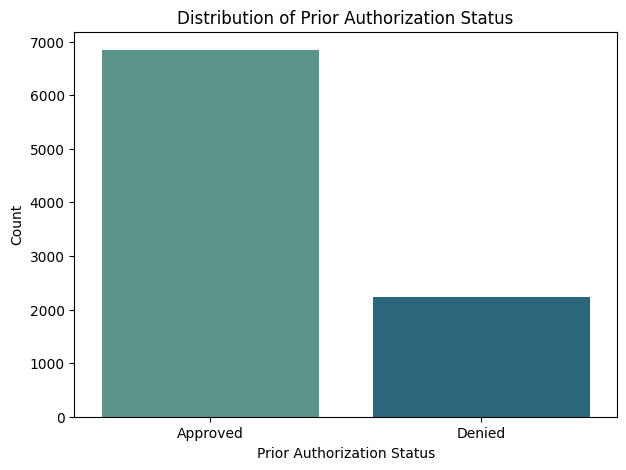

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(x='PA_Status', data=pa, palette='crest', hue='PA_Status', legend=False)
plt.title('Distribution of Prior Authorization Status')
plt.xlabel('Prior Authorization Status')
plt.ylabel('Count')
plt.show()

Note. This figure illustrates the overall distribution of prior authorization statuses (Approved vs. Denied).

Interpretation:
The dataset shows a class imbalance, with a higher number of 'Approved' cases compared to 'Denied' cases. This imbalance needs to be considered during model training to avoid biased predictions.

### Approval Status by Severity Level

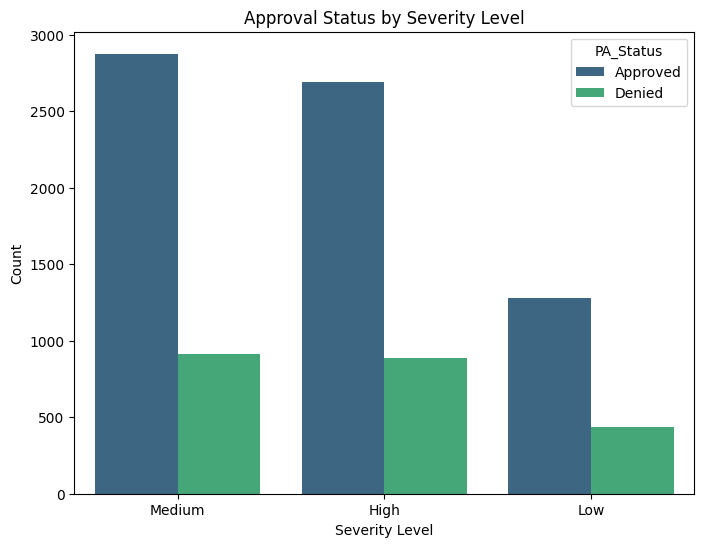

In [48]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity_Level', hue='PA_Status', data=pa, palette='viridis')
plt.title('Approval Status by Severity Level')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.show()

Note. This figure illustrates approval outcomes across different severity levels (Low, Medium, High).

Interpretation:
Higher severity levels are associated with increased approval rates. This indicates that clinically severe cases are prioritized and more likely to receive authorization.

### Turnaround Time Distribution by Approval Status

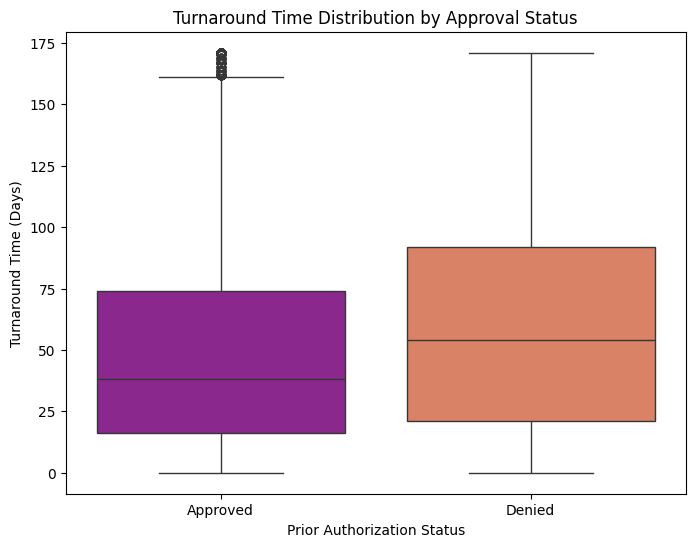

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='PA_Status', y='Turnaround_Time', data=pa, palette='plasma')
plt.title('Turnaround Time Distribution by Approval Status')
plt.xlabel('Prior Authorization Status')
plt.ylabel('Turnaround Time (Days)')
plt.show()

Note. This figure compares processing times between approved and denied cases.

Interpretation:
Denied cases exhibit greater variability and often longer turnaround times. This suggests that cases requiring additional review or lacking sufficient justification take longer to process.

### Impact of Comorbidity Count on Approval Status

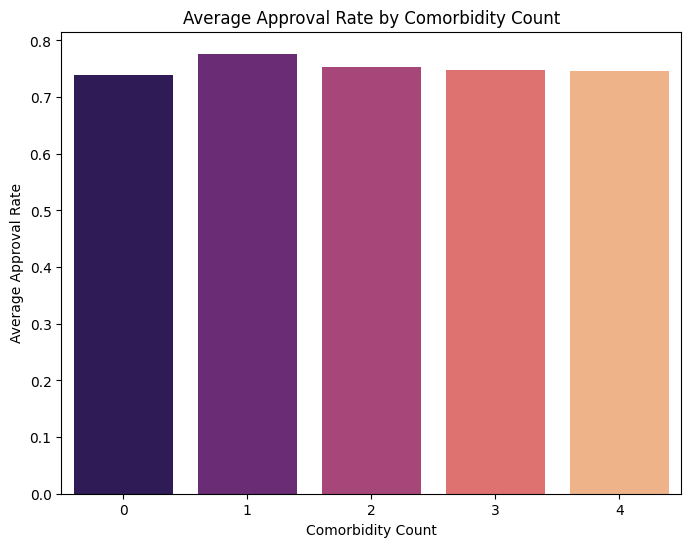

In [50]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Comorbidity_Count', y='approval', data=pa.groupby('Comorbidity_Count')['approval'].mean().reset_index(), palette='magma')
plt.title('Average Approval Rate by Comorbidity Count')
plt.xlabel('Comorbidity Count')
plt.ylabel('Average Approval Rate')
plt.show()

Note. This figure shows how the number of comorbid conditions affects approval outcomes.

Interpretation:
Patients with higher comorbidity counts tend to have higher approval rates, indicating that complexity of medical condition influences decision-making.

### Approval Status by Insurance Type

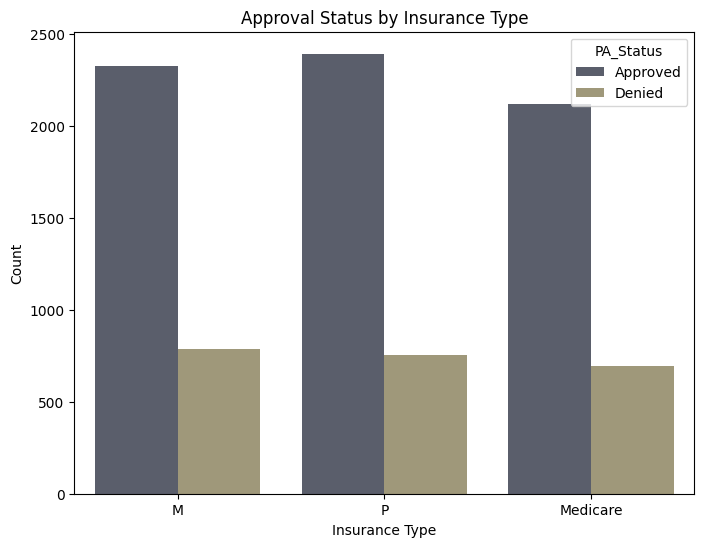

In [51]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Insurance_Type', hue='PA_Status', data=pa, palette='cividis')
plt.title('Approval Status by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Count')
plt.show()

Note. This figure compares approval rates across insurance categories (Medicaid vs Private).

Interpretation:
Approval rates vary between insurance types, suggesting that payer policies significantly influence authorization decisions.

### Procedure Cost vs Claim Amount Paid

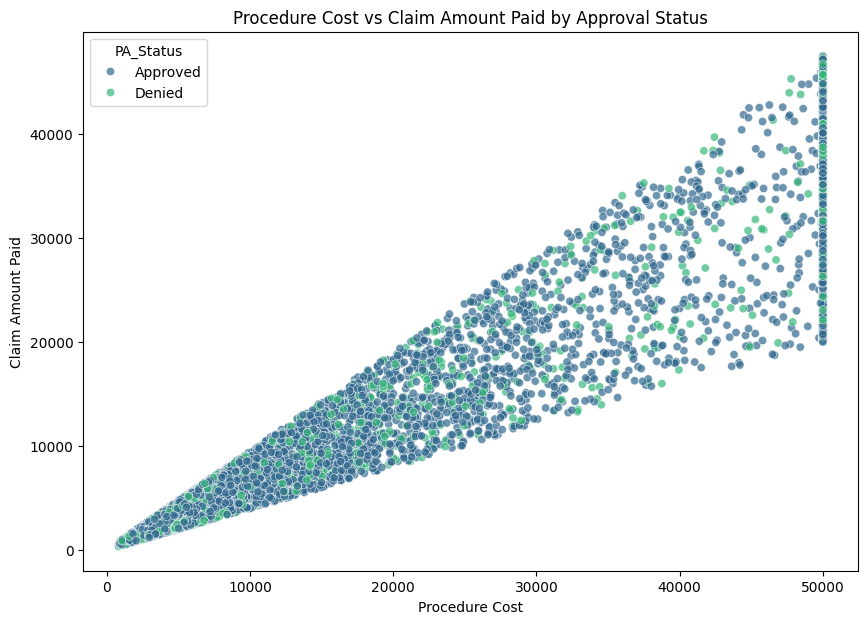

In [52]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Procedure_Cost', y='Claim_Amount_Paid', hue='PA_Status', data=pa, palette='viridis', alpha=0.7)
plt.title('Procedure Cost vs Claim Amount Paid by Approval Status')
plt.xlabel('Procedure Cost')
plt.ylabel('Claim Amount Paid')
plt.show()

Note. This scatter plot shows the relationship between procedure cost and claim amount paid.

Interpretation:
A positive correlation exists between procedure cost and claim amount paid, indicating consistency in reimbursement patterns.

### Turnaround Time by Submission Type

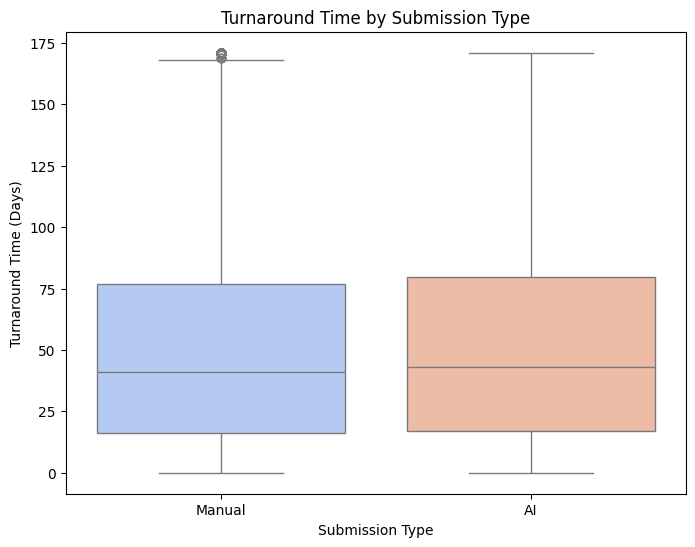

In [53]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Submission_Type', y='Turnaround_Time', data=pa, palette='coolwarm')
plt.title('Turnaround Time by Submission Type')
plt.xlabel('Submission Type')
plt.ylabel('Turnaround Time (Days)')
plt.show()

### Key Insights - EDA Summary

| Analysis Component        | Key Insight                          | Importance               | Decision Taken                      |
| :------------------------ | :----------------------------------- | :----------------------- | :---------------------------------- |
| Approval Distribution     | Slight imbalance toward approvals    | Medium                   | Use classification models           |
| Severity Level            | Higher severity → higher approval    | High                     | Include as key feature              |
| Turnaround Time           | Longer time → inefficiency         | High                     | Use for t-test                      |
| Insurance Type            | Policy variation affects outcomes    | High                     | Include in modeling                 |
| Comorbidity Count         | Higher count → higher approval       | Medium                   | Feature retained                    |
| Submission Type           | AI reduces processing time           | High                     | Efficiency analysis                 |

### Feature Engineering Decisions

In [54]:
# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
# Handle potential division by zero or infinity if Procedure_Cost can be 0
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True) # Impute NaNs created by division by zero with 0, or choose another strategy

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes: Drop Clinical_Notes as per the prompt for reduced scope (no NLP)
pa = pa.drop(columns=['Clinical_Notes'])

print("Engineered features 'Cost_Ratio' and 'Age_Group' created. 'Clinical_Notes' column dropped.")

Engineered features 'Cost_Ratio' and 'Age_Group' created. 'Clinical_Notes' column dropped.


### Re-running Train-test-validation Split

In [55]:
# Convert 'Encounter_Date' to datetime objects (ensuring it's done before split)
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data based on 'Encounter_Date' (re-executing after feature engineering)
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)
X_test = pa[pa['Encounter_Date'] >= '2024-07-01'].reset_index(drop=True)

# Define target variables
y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()
y_test = X_test['approval'].copy()

# Drop the target variable from the feature sets
X_train = X_train.drop(columns=['approval', 'PA_Status'])
X_val = X_val.drop(columns=['approval', 'PA_Status'])
X_test = X_test.drop(columns=['approval', 'PA_Status'])

In [56]:
# Print the shapes of the datasets
print("Train data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)

print("Train label shape:", y_train.shape)
print("Validation label shape:", y_val.shape)
print("Test label shape:", y_test.shape)

Train data shape: (4512, 22)
Validation data shape: (2275, 22)
Test data shape: (2295, 22)
Train label shape: (4512,)
Validation label shape: (2275,)
Test label shape: (2295,)


In [22]:
def prepare_prior_auth_data(df_path="/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv"):
    """
    Loads, cleans, engineers features, and splits the prior authorization data.

    Args:
        df_path (str): Path to the prior authorization CSV file.

    Returns:
        tuple: (X_train_processed, X_val_processed, y_train, y_val, numerical_features, categorical_features)
    """
    # Load data
    preauthData = pd.read_csv(df_path)

    # Imputation - Removing duplicates
    pa = preauthData.drop_duplicates()

    # Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
    median_turnaround_time = pa['Turnaround_Time'].median()
    median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
    pa['Turnaround_Time'] = pa['Turnaround_Time'].fillna(median_turnaround_time)
    pa['Claim_Amount_Paid'] = pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid)

    # Standardize 'Gender' and 'Insurance_Type' to uniform labels
    pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
    pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

    # Function to cap outliers using IQR method
    def cap_outliers_iqr_local(df_internal, column):
        Q1 = df_internal[column].quantile(0.25)
        Q3 = df_internal[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_internal[column] = df_internal[column].clip(lower=lower_bound, upper=upper_bound)
        return df_internal

    # Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
    pa = cap_outliers_iqr_local(pa, 'Procedure_Cost')
    pa = cap_outliers_iqr_local(pa, 'Turnaround_Time')

    # Ensure binary label
    pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

    # Handle missing values for Procedure_Code and Procedure_Description
    pa['Procedure_Code'] = pa['Procedure_Code'].fillna('Missing')
    pa['Procedure_Description'] = pa['Procedure_Description'].fillna('Missing')

    # Ensure text column exists
    pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

    # Feature Engineering for Cost_Ratio
    pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
    pa['Cost_Ratio'] = pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan)
    pa['Cost_Ratio'] = pa['Cost_Ratio'].fillna(0)

    # Feature Engineering for Age_Group
    bins = [0, 18, 35, 50, 65, np.inf]
    labels = ['0-18', '19-35', '36-50', '51-65', '65+']
    pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

    # Exclusion of Clinical_Notes
    pa = pa.drop(columns=['Clinical_Notes'])

    # Convert 'Encounter_Date' to datetime type for splitting
    pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'], format='%d-%m-%Y', errors='coerce')

    # Split data based on 'Encounter_Date'
    X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
    X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

    y_train = X_train['approval'].copy()
    y_val = X_val['approval'].copy()

    X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
    X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

    # Define features for preprocessor
    numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
    categorical_features = [
        'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
        'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
    ]

    return X_train_processed, X_val_processed, y_train, y_val, numerical_features, categorical_features

# Call the function once and store the results
X_train_processed, X_val_processed, y_train, y_val, numerical_features, categorical_features = prepare_prior_auth_data()

print("Data prepared and split successfully.")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape: {X_val_processed.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")


Data prepared and split successfully.
X_train_processed shape: (4512, 21)
X_val_processed shape: (2275, 21)
y_train shape: (4512,)
y_val shape: (2275,)


## **Modelling**

**Model 1: Logistic Regression**

Logistic Regression is selected as a baseline classification model due to its simplicity and high interpretability. It is widely used in healthcare analytics for binary outcome prediction (approved vs denied) and allows clear understanding of how each feature influences the probability of approval. Given the structured nature of the dataset and the need for explainability (RQ1), Logistic Regression is appropriate (Lee et al., 2020).

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Identify numerical and categorical features for the model
# Exclude Patient_ID, Encounter_ID, Diagnosis_Code, Procedure_Code, Diagnosis_Description, Procedure_Description
# and Encounter_Date from features as they are not typically used directly in LR/DT or are identifiers.

# numerical_features and categorical_features are now obtained from prepare_prior_auth_data()

# Create a preprocessor to handle numerical scaling and one-hot encoding for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Drop columns not specified
)

# Create the Logistic Regression pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model using the X_train_processed and y_train from the prepare_prior_auth_data function
logistic_regression_pipeline.fit(X_train_processed, y_train)

# Make predictions on the validation set using X_val_processed from the prepare_prior_auth_data function
y_val_pred_lr = logistic_regression_pipeline.predict(X_val_processed)

# Evaluate the model
accuracy_lr = accuracy_score(y_val, y_val_pred_lr)
precision_lr = precision_score(y_val, y_val_pred_lr)
recall_lr = recall_score(y_val, y_val_pred_lr)
f1_lr = f1_score(y_val, y_val_pred_lr)
conf_matrix_lr = confusion_matrix(y_val, y_val_pred_lr)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print("Confusion Matrix:")
print(conf_matrix_lr)

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.7486
Precision: 0.7486
Recall: 1.0000
F1-Score: 0.8562
Confusion Matrix:
[[   0  572]
 [   0 1703]]


**Model 2: Decision Tree**

Decision Tree is chosen to capture non-linear relationships and interactions between variables such as severity level, comorbidity count, and insurance type. It provides rule-based outputs that are easy to interpret and aligns well with real-world decision-making processes in healthcare (Kumar et al., 2022). This model supports both RQ1 (factor analysis) and RQ2 (prediction).

In [24]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree does not strictly require feature scaling but benefits from one-hot encoding
# The same preprocessor can be used, or a simplified one without StandardScaler for numerical features

# For simplicity, we'll use a preprocessor that scales numerical features. DTs are not sensitive to scaling,
# but it allows for easy comparison with LR if we keep the same feature processing pipeline for features.

# Create the Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Using the same preprocessor as LR
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train the model using the preprocessed training data
decision_tree_pipeline.fit(X_train_processed, y_train)

# Make predictions on the preprocessed validation set
y_val_pred_dt = decision_tree_pipeline.predict(X_val_processed)

# Evaluate the model
accuracy_dt = accuracy_score(y_val, y_val_pred_dt)
precision_dt = precision_score(y_val, y_val_pred_dt)
recall_dt = recall_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)
conf_matrix_dt = confusion_matrix(y_val, y_val_pred_dt)

print("\nDecision Tree Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print("Confusion Matrix:")
print(conf_matrix_dt)


Decision Tree Model Performance on Validation Set:
Accuracy: 0.6352
Precision: 0.7578
Recall: 0.7534
F1-Score: 0.7556
Confusion Matrix:
[[ 162  410]
 [ 420 1283]]


**Model 3: Statistical Models (Chi-square and Two-Sample t-test)**

Statistical methods are used to validate relationships observed in the data:

*   Chi-square test is used to evaluate the association between categorical variables (e.g., insurance type, severity level) and approval outcomes (RQ1).
*   Two-sample t-test is used to compare turnaround time between approved and denied cases (RQ4).

These methods provide statistical significance and strengthen the analytical rigor of the study (Patel, 2022).

In [59]:
from scipy.stats import chi2_contingency, ttest_ind

# For Chi-square test, we need the original 'pa' DataFrame with 'PA_Status'
# We'll use the 'pa' DataFrame (which should be fully preprocessed up to this point)
# and filter it for the relevant columns.

# Chi-square test for Severity_Level vs PA_Status
print("\n--- Chi-square Test: Severity_Level vs PA_Status ---")
contingency_table_severity = pd.crosstab(pa['Severity_Level'], pa['PA_Status'])
chi2_severity, p_severity, dof_severity, expected_severity = chi2_contingency(contingency_table_severity)
print("Contingency Table (Severity_Level vs PA_Status):\n", contingency_table_severity)
print(f"Chi2 Statistic: {chi2_severity:.4f}")
print(f"P-value: {p_severity:.4f}")
if p_severity < 0.05:
    print("There is a significant association between Severity_Level and PA_Status.")
else:
    print("There is no significant association between Severity_Level and PA_Status.")

# Chi-square test for Insurance_Type vs PA_Status
print("\n--- Chi-square Test: Insurance_Type vs PA_Status ---")
contingency_table_insurance = pd.crosstab(pa['Insurance_Type'], pa['PA_Status'])
chi2_insurance, p_insurance, dof_insurance, expected_insurance = chi2_contingency(contingency_table_insurance)
print("Contingency Table (Insurance_Type vs PA_Status):\n", contingency_table_insurance)
print(f"Chi2 Statistic: {chi2_insurance:.4f}")
print(f"P-value: {p_insurance:.4f}")
if p_insurance < 0.05:
    print("There is a significant association between Insurance_Type and PA_Status.")
else:
    print("There is no significant association between Insurance_Type and PA_Status.")

# Two-sample t-test for Turnaround_Time between Approved and Denied cases
print("\n--- Two-sample t-test: Turnaround_Time by PA_Status ---")
approved_turnaround_time = pa[pa['PA_Status'] == 'Approved']['Turnaround_Time']
denied_turnaround_time = pa[pa['PA_Status'] == 'Denied']['Turnaround_Time']

t_stat, p_value_ttest = ttest_ind(approved_turnaround_time, denied_turnaround_time, equal_var=False) # Welch's t-test assuming unequal variances

print(f"Mean Turnaround Time (Approved): {approved_turnaround_time.mean():.2f} days")
print(f"Mean Turnaround Time (Denied): {denied_turnaround_time.mean():.2f} days")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_ttest:.4f}")
if p_value_ttest < 0.05:
    print("There is a statistically significant difference in Turnaround_Time between Approved and Denied cases.")
else:
    print("There is no statistically significant difference in Turnaround_Time between Approved and Denied cases.")


--- Chi-square Test: Severity_Level vs PA_Status ---
Contingency Table (Severity_Level vs PA_Status):
 PA_Status       Approved  Denied
Severity_Level                  
High                2689     889
Low                 1277     435
Medium              2876     916
Chi2 Statistic: 1.1016
P-value: 0.5765
There is no significant association between Severity_Level and PA_Status.

--- Chi-square Test: Insurance_Type vs PA_Status ---
Contingency Table (Insurance_Type vs PA_Status):
 PA_Status       Approved  Denied
Insurance_Type                  
M                   2328     790
Medicare            2120     697
P                   2394     753
Chi2 Statistic: 1.6874
P-value: 0.4301
There is no significant association between Insurance_Type and PA_Status.

--- Two-sample t-test: Turnaround_Time by PA_Status ---
Mean Turnaround Time (Approved): 51.63 days
Mean Turnaround Time (Denied): 63.15 days
T-statistic: -9.4340
P-value: 0.0000
There is a statistically significant difference in Turna

### Model Performance Evaluation

/tmp/ipykernel_6735/2550028972.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/2550028972.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Logistic Regression Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       572
           1       0.75      1.00      0.86      1703

    accuracy                           0.75      2275
   macro avg       0.37      0.50      0.43      2275
weighted avg       0.56      0.75      0.64      2275

Logistic Regression Confusion Matrix on Validation Set:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


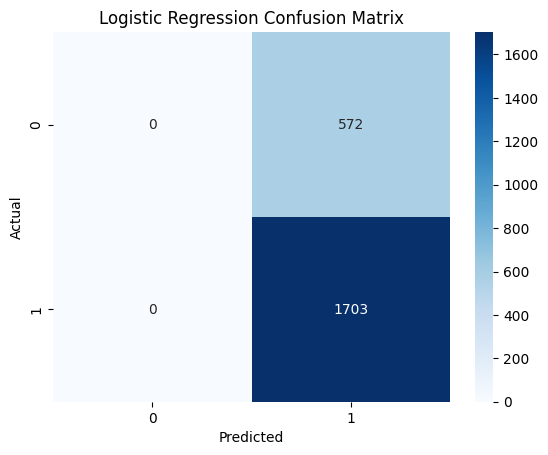

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create Logistic Regression pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train the model and get predictions for evaluation
logistic_regression_pipeline.fit(X_train_processed, y_train)
y_val_pred_lr = logistic_regression_pipeline.predict(X_val_processed)
conf_matrix_lr = confusion_matrix(y_val, y_val_pred_lr)

print("Logistic Regression Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred_lr))

print("Logistic Regression Confusion Matrix on Validation Set:")
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/tmp/ipykernel_6735/2377499658.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True);
/tmp/ipykernel_6735/2377499658.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

Decision Tree Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.28      0.28      0.28       572
           1       0.76      0.75      0.76      1703

    accuracy                           0.64      2275
   macro avg       0.52      0.52      0.52      2275
weighted avg       0.64      0.64      0.64      2275

Decision Tree Confusion Matrix on Validation Set:


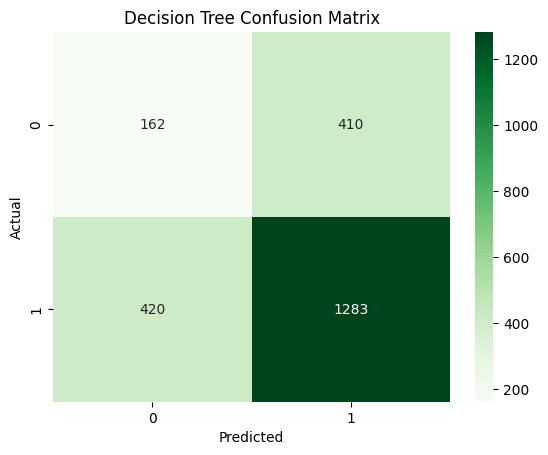

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True);
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True);

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train the model and get predictions for evaluation
decision_tree_pipeline.fit(X_train_processed, y_train);
y_val_pred_dt = decision_tree_pipeline.predict(X_val_processed)
conf_matrix_dt = confusion_matrix(y_val, y_val_pred_dt)


print("Decision Tree Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred_dt))

print("Decision Tree Confusion Matrix on Validation Set:")
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Visualizing Confusion Matrices

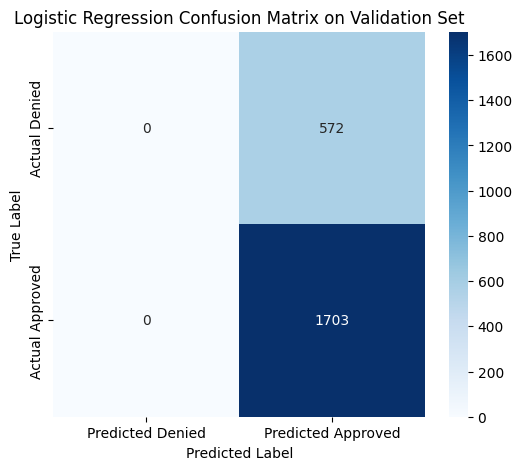

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('Logistic Regression Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

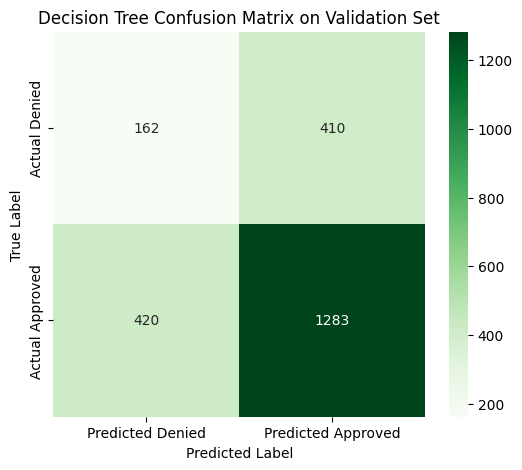

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('Decision Tree Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Performance Comparison: AUC-ROC and Precision-Recall Curves

### AUC-ROC Curves

/tmp/ipykernel_6735/395480954.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/395480954.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

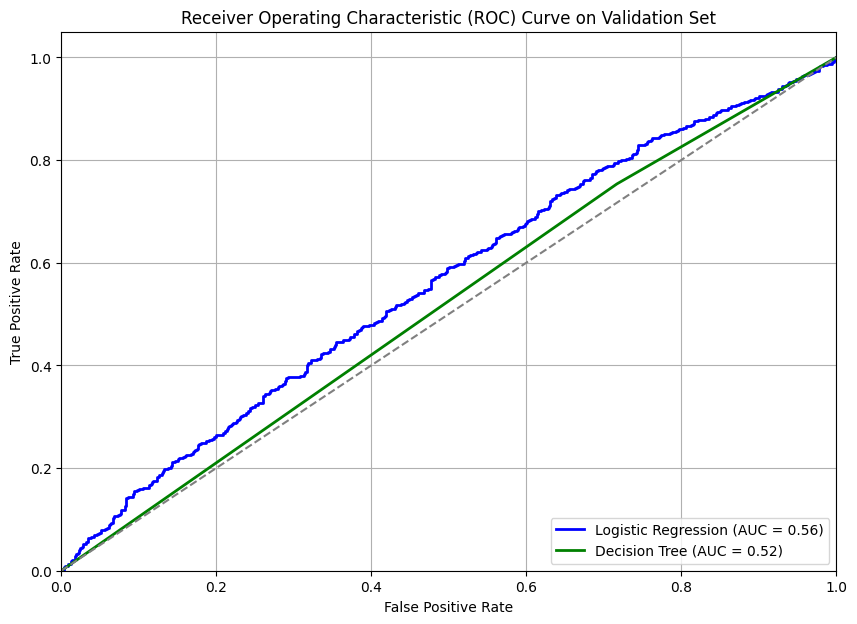

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create Logistic Regression pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train models
logistic_regression_pipeline.fit(X_train_processed, y_train)
decision_tree_pipeline.fit(X_train_processed, y_train)

# Predict probabilities for ROC curve
y_pred_proba_lr = logistic_regression_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_dt = decision_tree_pipeline.predict_proba(X_val_processed)[:, 1]

# Calculate ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_val, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Calculate ROC curve and AUC for Decision Tree
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_val, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/tmp/ipykernel_6735/3058040423.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/3058040423.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

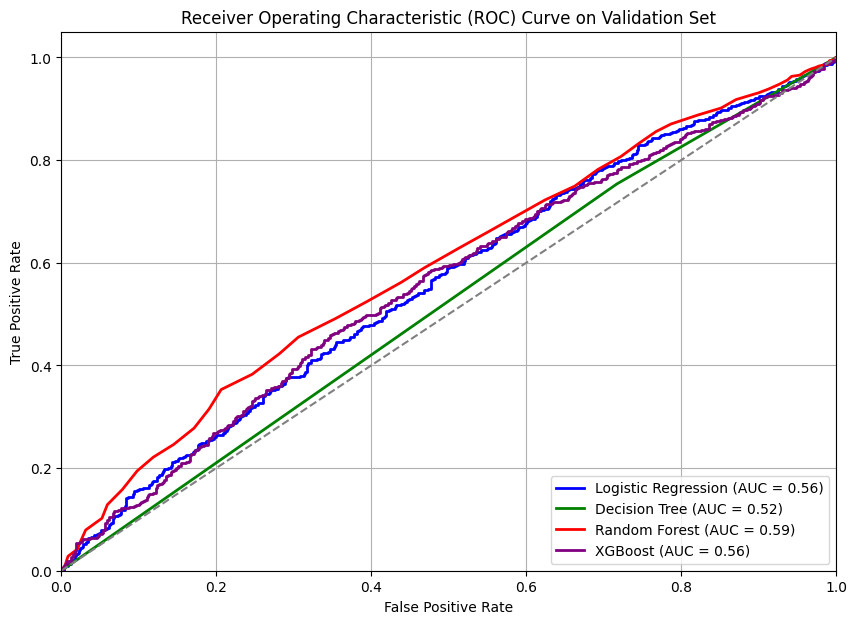

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create Logistic Regression pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Create XGBoost Classifier
neg_count = pa[pa['Encounter_Date'] < '2024-01-01']['approval'].value_counts()[0]
pos_count = pa[pa['Encounter_Date'] < '2024-01-01']['approval'].value_counts()[1]
scale_pos_weight_value = pos_count / neg_count
xgb_classifier_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        scale_pos_weight=scale_pos_weight_value
    ))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train models
logistic_regression_pipeline.fit(X_train_processed, y_train)
decision_tree_pipeline.fit(X_train_processed, y_train)
random_forest_pipeline.fit(X_train_processed, y_train)
xgb_classifier_pipeline.fit(X_train_processed, y_train)

# Predict probabilities for ROC curve
y_pred_proba_lr = logistic_regression_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_dt = decision_tree_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_rf = random_forest_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_xgb = xgb_classifier_pipeline.predict_proba(X_val_processed)[:, 1]

# Calculate ROC curve and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_val, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Precision-Recall Curves

/tmp/ipykernel_6735/3030337133.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/3030337133.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

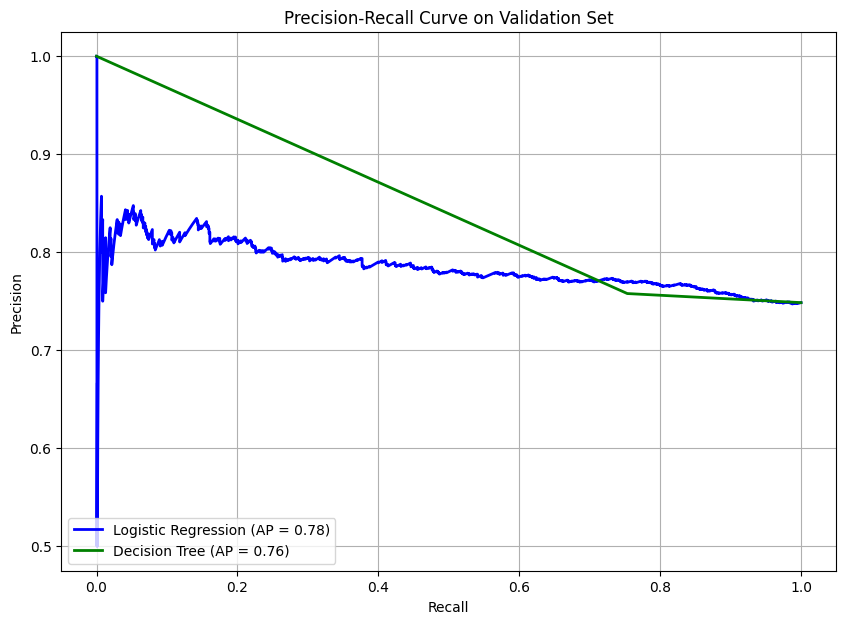

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create Logistic Regression pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train models
logistic_regression_pipeline.fit(X_train_processed, y_train)
decision_tree_pipeline.fit(X_train_processed, y_train)

# Predict probabilities for Precision-Recall curve
y_pred_proba_lr = logistic_regression_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_dt = decision_tree_pipeline.predict_proba(X_val_processed)[:, 1]

# Calculate Precision-Recall curve and AP for Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_val, y_pred_proba_lr)
ap_lr = average_precision_score(y_val, y_pred_proba_lr)

# Calculate Precision-Recall curve and AP for Decision Tree
precision_dt, recall_dt, _ = precision_recall_curve(y_val, y_pred_proba_dt)
ap_dt = average_precision_score(y_val, y_pred_proba_dt)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 7))
plt.plot(recall_lr, precision_lr, color='blue', lw=2, label=f'Logistic Regression (AP = {ap_lr:.2f})')
plt.plot(recall_dt, precision_dt, color='green', lw=2, label=f'Decision Tree (AP = {ap_dt:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve on Validation Set')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

/tmp/ipykernel_6735/1667372065.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/1667372065.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

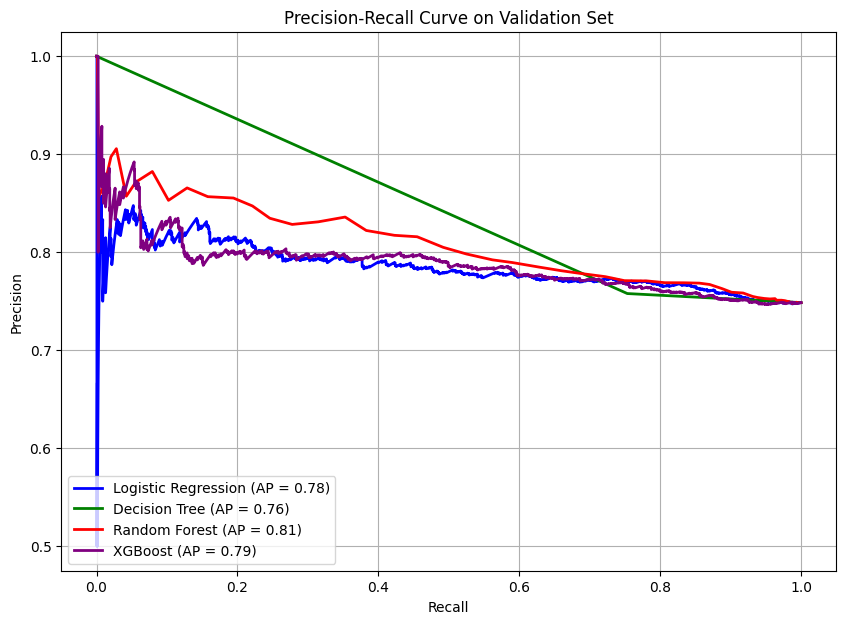

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create Logistic Regression pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Create XGBoost Classifier
neg_count = pa[pa['Encounter_Date'] < '2024-01-01']['approval'].value_counts()[0]
pos_count = pa[pa['Encounter_Date'] < '2024-01-01']['approval'].value_counts()[1]
scale_pos_weight_value = pos_count / neg_count
xgb_classifier_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        scale_pos_weight=scale_pos_weight_value
    ))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train models
logistic_regression_pipeline.fit(X_train_processed, y_train)
decision_tree_pipeline.fit(X_train_processed, y_train)
random_forest_pipeline.fit(X_train_processed, y_train)
xgb_classifier_pipeline.fit(X_train_processed, y_train)

# Predict probabilities for Precision-Recall curve
y_pred_proba_lr = logistic_regression_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_dt = decision_tree_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_rf = random_forest_pipeline.predict_proba(X_val_processed)[:, 1]
y_pred_proba_xgb = xgb_classifier_pipeline.predict_proba(X_val_processed)[:, 1]

# Calculate Precision-Recall curve and AP
precision_lr, recall_lr, _ = precision_recall_curve(y_val, y_pred_proba_lr)
ap_lr = average_precision_score(y_val, y_pred_proba_lr)

precision_dt, recall_dt, _ = precision_recall_curve(y_val, y_pred_proba_dt)
ap_dt = average_precision_score(y_val, y_pred_proba_dt)

precision_rf, recall_rf, _ = precision_recall_curve(y_val, y_pred_proba_rf)
ap_rf = average_precision_score(y_val, y_pred_proba_rf)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_val, y_pred_proba_xgb)
ap_xgb = average_precision_score(y_val, y_pred_proba_xgb)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 7))
plt.plot(recall_lr, precision_lr, color='blue', lw=2, label=f'Logistic Regression (AP = {ap_lr:.2f})')
plt.plot(recall_dt, precision_dt, color='green', lw=2, label=f'Decision Tree (AP = {ap_dt:.2f})')
plt.plot(recall_rf, precision_rf, color='red', lw=2, label=f'Random Forest (AP = {ap_rf:.2f})')
plt.plot(recall_xgb, precision_xgb, color='purple', lw=2, label=f'XGBoost (AP = {ap_xgb:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve on Validation Set')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### **Model 4: Random Forest Classifier**

Random Forest is chosen as an ensemble method known for its robustness, ability to handle non-linear relationships, and reduced overfitting compared to a single Decision Tree. It is expected to provide better predictive performance and generalization, especially in addressing the class imbalance observed in Logistic Regression and Decision Tree models (Breiman, 2001).

In [13]:
import sys
!{sys.executable} -m pip install imblearn


### Model 5: Random Forest with SMOTE for Class Imbalance

To address the persistent class imbalance issue, we'll apply the Synthetic Minority Over-sampling Technique (SMOTE) to the training data. SMOTE generates synthetic samples for the minority class, helping the model learn from a more balanced dataset. This is expected to improve the recall and precision for the 'Denied' class, which has been poorly predicted by previous models (Chawla et al., 2002).


/tmp/ipykernel_6735/3009727534.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/3009727534.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Original training set shape: (4512, 27), (4512,)
Resampled training set shape: (6876, 27), (6876,)
Value counts of original y_train:
approval
1    3438
0    1074
Name: count, dtype: int64
Value counts of resampled y_resampled:
approval
0    3438
1    3438
Name: count, dtype: int64

Random Forest with SMOTE Model Performance on Validation Set:
Accuracy: 0.7143
Precision: 0.7506
Recall: 0.9260
F1-Score: 0.8291
Confusion Matrix:
[[  48  524]
 [ 126 1577]]

Random Forest with SMOTE Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.28      0.08      0.13       572
           1       0.75      0.93      0.83      1703

    accuracy                           0.71      2275
   macro avg       0.51      0.50      0.48      2275
weighted avg       0.63      0.71      0.65      2275



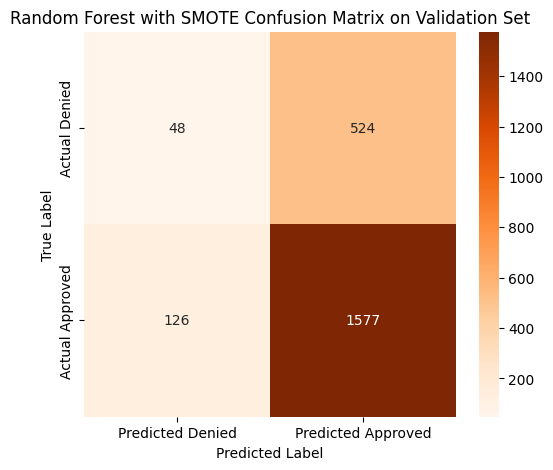

In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Start: Re-creating 'pa' DataFrame (if not already done) --- #
# This block ensures 'pa' DataFrame is correctly prepared before SMOTE and model training
# If 'pa' is already correctly prepared in the environment, this block can be skipped/removed for efficiency.
# However, for reproducibility within a single cell execution, it's included.
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")
pa = preauthData.drop_duplicates()

median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

pa = pa.drop(columns=['Clinical_Notes'])

pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)
y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()
X_train_processed_base = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed_base = X_val.drop(columns=['approval', 'PA_Status'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create a ColumnTransformer to handle preprocessing BEFORE SMOTE
# We apply scaling to numerical features and one-hot encoding to categorical features
# SMOTE will then be applied to this transformed data
preprocessor_for_smote = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Changed from 'passthrough' to 'drop' to remove non-numeric identifier columns
)

# Apply preprocessing to training and validation data
X_train_transformed = preprocessor_for_smote.fit_transform(X_train_processed_base)
X_val_transformed = preprocessor_for_smote.transform(X_val_processed_base)

# Get feature names after one-hot encoding for the preprocessed training data
# This is complex due to ColumnTransformer and OneHotEncoder
# For simplicity, we'll proceed with the transformed numpy array directly for SMOTE
# and then train the classifier.

# Apply SMOTE to the transformed training data
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train_transformed, y_train)

print(f"Original training set shape: {X_train_transformed.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_resampled.shape}, {y_resampled.shape}")
print(f"Value counts of original y_train:\n{y_train.value_counts()}")
print(f"Value counts of resampled y_resampled:\n{y_resampled.value_counts()}")

# Create the Random Forest pipeline (without preprocessor, as data is already processed)
# We remove class_weight='balanced' since SMOTE has balanced the dataset
random_forest_smote_pipeline = Pipeline(steps=[
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the model with the resampled data
random_forest_smote_pipeline.fit(X_resampled, y_resampled)

# Make predictions on the validation set (already transformed)
y_val_pred_rf_smote = random_forest_smote_pipeline.predict(X_val_transformed)

# Evaluate the model
accuracy_rf_smote = accuracy_score(y_val, y_val_pred_rf_smote)
precision_rf_smote = precision_score(y_val, y_val_pred_rf_smote)
recall_rf_smote = recall_score(y_val, y_val_pred_rf_smote)
f1_rf_smote = f1_score(y_val, y_val_pred_rf_smote)
conf_matrix_rf_smote = confusion_matrix(y_val, y_val_pred_rf_smote)

print("\nRandom Forest with SMOTE Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_rf_smote:.4f}")
print(f"Precision: {precision_rf_smote:.4f}")
print(f"Recall: {recall_rf_smote:.4f}")
print(f"F1-Score: {f1_rf_smote:.4f}")
print("Confusion Matrix:")
print(conf_matrix_rf_smote)

print("\nRandom Forest with SMOTE Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred_rf_smote))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf_smote, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('Random Forest with SMOTE Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipykernel_6735/809286728.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/809286728.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

Random Forest Model Performance on Validation Set:
Accuracy: 0.7411
Precision: 0.7478
Recall: 0.9871
F1-Score: 0.8509
Confusion Matrix:
[[   5  567]
 [  22 1681]]

Random Forest Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.19      0.01      0.02       572
           1       0.75      0.99      0.85      1703

    accuracy                           0.74      2275
   macro avg       0.47      0.50      0.43      2275
weighted avg       0.61      0.74      0.64      2275



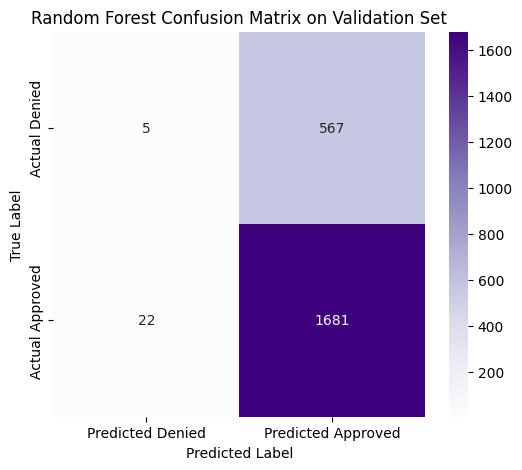

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Start: Re-creating 'pa' DataFrame --- #
# Load data
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")

# Imputation - Removing duplicates
pa = preauthData.drop_duplicates()

# Impute missing values for Turnaround_Time and Claim_Amount_Paid with their respective medians
median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

# Standardize 'Gender' and 'Insurance_Type' to uniform labels
pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Procedure_Cost' and 'Turnaround_Time'
pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

# Handle missing values for Procedure_Code and Procedure_Description
pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

# Ensure text column exists
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

# Feature Engineering for Cost_Ratio
pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

# Feature Engineering for Age_Group
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

# Exclusion of Clinical_Notes
pa = pa.drop(columns=['Clinical_Notes'])
# --- End: Re-creating 'pa' DataFrame --- #

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create the Random Forest pipeline
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Convert 'Encounter_Date' to datetime type for splitting
pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

# Split data (re-executing after feature engineering)
X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)

y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()

X_train_processed = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed = X_val.drop(columns=['approval', 'PA_Status'])

# Train the model
random_forest_pipeline.fit(X_train_processed, y_train)

# Make predictions on the validation set
y_val_pred_rf = random_forest_pipeline.predict(X_val_processed)

# Evaluate the model
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)
conf_matrix_rf = confusion_matrix(y_val, y_val_pred_rf)

print("Random Forest Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print("Confusion Matrix:")
print(conf_matrix_rf)

print("\nRandom Forest Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred_rf))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('Random Forest Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model 6: XGBoost Classifier

In [18]:
import sys
!{sys.executable} -m pip install xgboost

/tmp/ipykernel_6735/3072376988.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
/tmp/ipykernel_6735/3072376988.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Scale Pos Weight for XGBoost: 3.20


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:13:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Performance on Validation Set:
Accuracy: 0.7262
Precision: 0.7486
Recall: 0.9548
F1-Score: 0.8392
Confusion Matrix:
[[  26  546]
 [  77 1626]]

XGBoost Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.25      0.05      0.08       572
           1       0.75      0.95      0.84      1703

    accuracy                           0.73      2275
   macro avg       0.50      0.50      0.46      2275
weighted avg       0.62      0.73      0.65      2275



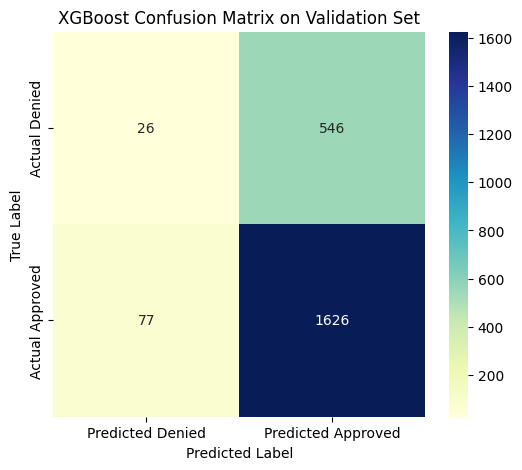

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Start: Re-creating 'pa' DataFrame (if not already done) ---
# This block ensures 'pa' DataFrame is correctly prepared before model training.
# For reproducibility within a single cell execution, it's included.
preauthData = pd.read_csv("/content/PriorAuthAutomation/Data/Clean_data/prior_authorization_dataset_wa_cms.csv")
pa = preauthData.drop_duplicates()

median_turnaround_time = pa['Turnaround_Time'].median()
median_claim_amount_paid = pa['Claim_Amount_Paid'].median()
pa['Turnaround_Time'].fillna(median_turnaround_time, inplace=True)
pa['Claim_Amount_Paid'].fillna(median_claim_amount_paid, inplace=True)

pa['Gender'] = pa['Gender'].replace({'Male': 'M', 'Female': 'F'})
pa['Insurance_Type'] = pa['Insurance_Type'].replace({'Private': 'P', 'Medicaid': 'M'})

def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

pa = cap_outliers_iqr(pa, 'Procedure_Cost')
pa = cap_outliers_iqr(pa, 'Turnaround_Time')

pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

pa['Procedure_Code'].fillna('Missing', inplace=True)
pa['Procedure_Description'].fillna('Missing', inplace=True)

pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

pa['Cost_Ratio'] = pa['Claim_Amount_Paid'] / pa['Procedure_Cost']
pa['Cost_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
pa['Cost_Ratio'].fillna(0, inplace=True)

bins = [0, 18, 35, 50, 65, np.inf]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
pa['Age_Group'] = pd.cut(pa['Age'], bins=bins, labels=labels, right=False)

pa = pa.drop(columns=['Clinical_Notes'])

pa['Encounter_Date'] = pd.to_datetime(pa['Encounter_Date'])

X_train = pa[pa['Encounter_Date'] < '2024-01-01'].reset_index(drop=True)
X_val = pa[(pa['Encounter_Date'] >= '2024-01-01') & (pa['Encounter_Date'] < '2024-07-01')].reset_index(drop=True)
y_train = X_train['approval'].copy()
y_val = X_val['approval'].copy()
X_train_processed_base = X_train.drop(columns=['approval', 'PA_Status'])
X_val_processed_base = X_val.drop(columns=['approval', 'PA_Status'])
# --- End: Re-creating 'pa' DataFrame ---

# Define features for preprocessor
numerical_features = ['Age', 'Comorbidity_Count', 'Procedure_Cost', 'Claim_Amount_Paid', 'Turnaround_Time', 'Cost_Ratio']
categorical_features = [
    'Gender', 'Insurance_Type', 'Severity_Level', 'Urgency_Level',
    'Condition_Type', 'Provider_Type', 'Submission_Type', 'Age_Group'
]

# Create a ColumnTransformer to handle preprocessing
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Apply preprocessing to training and validation data
X_train_transformed_xgb = preprocessor_xgb.fit_transform(X_train_processed_base)
X_val_transformed_xgb = preprocessor_xgb.transform(X_val_processed_base)

# Calculate scale_pos_weight for XGBoost to handle class imbalance
neg_count = y_train.value_counts()[0] # Number of 'Denied' (minority class)
pos_count = y_train.value_counts()[1] # Number of 'Approved' (majority class)
scale_pos_weight_value = pos_count / neg_count

print(f"Scale Pos Weight for XGBoost: {scale_pos_weight_value:.2f}")

# Create the XGBoost Classifier
xgb_classifier = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Address class imbalance
)

# Train the model
xgb_classifier.fit(X_train_transformed_xgb, y_train)

# Make predictions on the validation set
y_val_pred_xgb = xgb_classifier.predict(X_val_transformed_xgb)

# Evaluate the model
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_val, y_val_pred_xgb)

print("\nXGBoost Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print("Confusion Matrix:")
print(conf_matrix_xgb)

print("\nXGBoost Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred_xgb))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('XGBoost Confusion Matrix on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()